# Integrantes
- Vinicius Torralles, Rm: 570911
- Mariana Carminato, Rm: 573258
- Gabriel Jurado, Rm: 571236

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

In [2]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"
parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}
response = requests.get(url, params=parametros, timeout=30)
print("Status:", response.status_code)
response.raise_for_status()
dados_json = response.json()

Status: 200


In [4]:
if isinstance(dados_json, list):
    registros = dados_json
elif isinstance(dados_json, dict):
    chaves_com_lista = [chave for chave, valor in dados_json.items() if isinstance(valor, list)]
    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")
    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)
else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo de registros:", type(registros))
print("Quantidade de registros:", len(registros))
if registros:
    print("\nPrimeiro registro:", registros[0])

Tipo de registros: <class 'list'>
Quantidade de registros: 336

Primeiro registro: {'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [5]:
# Desenvolva aqui o DESAFIO 1

dados = pd.DataFrame(registros)
print("\n--- DESAFIO 1 ---")
display(dados.head())
print(f"Linhas: {dados.shape[0]}, Colunas: {dados.shape[1]}")
print("Atributos:", dados.columns.tolist())
dados.info()
display(dados.describe())


--- DESAFIO 1 ---


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


Linhas: 336, Colunas: 11
Atributos: ['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    floa

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


In [7]:
print("Colunas disponíveis:", dados.columns.tolist())
print("\nExemplo de primeiro registro:")
print(registros[0])

Colunas disponíveis: ['cod_area', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']

Exemplo de primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [8]:
# Desenvolva aqui o DESAFIO 2

print("\n--- DESAFIO 2 ---")
dados_filtrados = dados[['cod_area', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal']].copy()

dados_filtrados.rename(columns={
    'cod_area': 'cod_area',
    'dat_referencia': 'data',
    'din_referenciautc': 'datetime',
    'val_cargaglobal': 'carga_mw'
}, inplace=True)

dados_filtrados['datetime'] = pd.to_datetime(dados_filtrados['datetime'], errors='coerce')

dados_filtrados['data'] = dados_filtrados['datetime'].dt.strftime('%Y-%m-%d')
dados_filtrados['hora'] = dados_filtrados['datetime'].dt.strftime('%H:%M:%S')

print("Valores ausentes por coluna:")
print(dados_filtrados.isnull().sum())

dados_filtrados['carga_mw'] = pd.to_numeric(dados_filtrados['carga_mw'], errors='coerce')
print("Tipo da carga:", dados_filtrados['carga_mw'].dtype)

print("\nDataFrame após organização:")
display(dados_filtrados.head())


--- DESAFIO 2 ---
Valores ausentes por coluna:
cod_area    0
data        0
datetime    0
carga_mw    0
hora        0
dtype: int64
Tipo da carga: float64

DataFrame após organização:


,cod_area,data,datetime,carga_mw,hora
0,SP,2025-08-01,2025-08-01 03:30:00+00:00,15913.618,03:30:00
1,SP,2025-08-01,2025-08-01 04:00:00+00:00,15251.414,04:00:00
2,SP,2025-08-01,2025-08-01 04:30:00+00:00,14606.733,04:30:00
3,SP,2025-08-01,2025-08-01 05:00:00+00:00,14182.290,05:00:00
4,SP,2025-08-01,2025-08-01 05:30:00+00:00,13838.488,05:30:00


In [9]:
# Desenvolva aqui o DESAFIO 3

print("\n--- DESAFIO 3 ---")

carga = dados_filtrados['carga_mw'].dropna()
min_carga = carga.min()
max_carga = carga.max()
media_carga = carga.mean()
mediana_carga = carga.median()
amplitude = max_carga - min_carga
total_medicoes = len(carga)

print(f"Carga mínima: {min_carga:.2f} MW")
print(f"Carga máxima: {max_carga:.2f} MW")
print(f"Carga média: {media_carga:.2f} MW")
print(f"Mediana: {mediana_carga:.2f} MW")
print(f"Amplitude: {amplitude:.2f} MW")
print(f"Total de medições: {total_medicoes}")

dist_rel = (max_carga - media_carga) / media_carga * 100
print(f"Máximo está {dist_rel:.1f}% acima da média.")


--- DESAFIO 3 ---
Carga mínima: 12139.25 MW
Carga máxima: 23185.31 MW
Carga média: 17870.83 MW
Mediana: 18199.13 MW
Amplitude: 11046.06 MW
Total de medições: 336
Máximo está 29.7% acima da média.


In [10]:
# Desenvolva aqui o DESAFIO 4
print("\n--- DESAFIO 4 ---")

limiar = 0.9 * max_carga
alta_demanda = dados_filtrados[dados_filtrados['carga_mw'] > limiar].copy()
qtde_alta = len(alta_demanda)
perc_alta = (qtde_alta / total_medicoes) * 100
print(f"Limiar: {limiar:.2f} MW")
print(f"Registros alta demanda: {qtde_alta}")
print(f"Percentual: {perc_alta:.2f}%")

pico = dados_filtrados.loc[dados_filtrados['carga_mw'].idxmax()]
print(f"Pico: {max_carga:.2f} MW em {pico['data']} às {pico['hora']}")


--- DESAFIO 4 ---
Limiar: 20866.78 MW
Registros alta demanda: 50
Percentual: 14.88%
Pico: 23185.31 MW em 2025-08-01 às 22:00:00


In [11]:
# Desenvolva aqui o DESAFIO 5
print("\n--- DESAFIO 5 ---")

media = dados_filtrados['carga_mw'].mean()
segundo_criterio = dados_filtrados[dados_filtrados['carga_mw'] > media].copy()
qtde_segundo = len(segundo_criterio)
perc_segundo = (qtde_segundo / total_medicoes) * 100
print(f"Critério: carga acima da média ({media:.2f} MW)")
print(f"Registros: {qtde_segundo}")
print(f"Percentual: {perc_segundo:.2f}%")


--- DESAFIO 5 ---

--- DESAFIO 5 ---
Critério: carga acima da média (17870.83 MW)
Registros: 184
Percentual: 54.76%



--- DESAFIO 6 ---


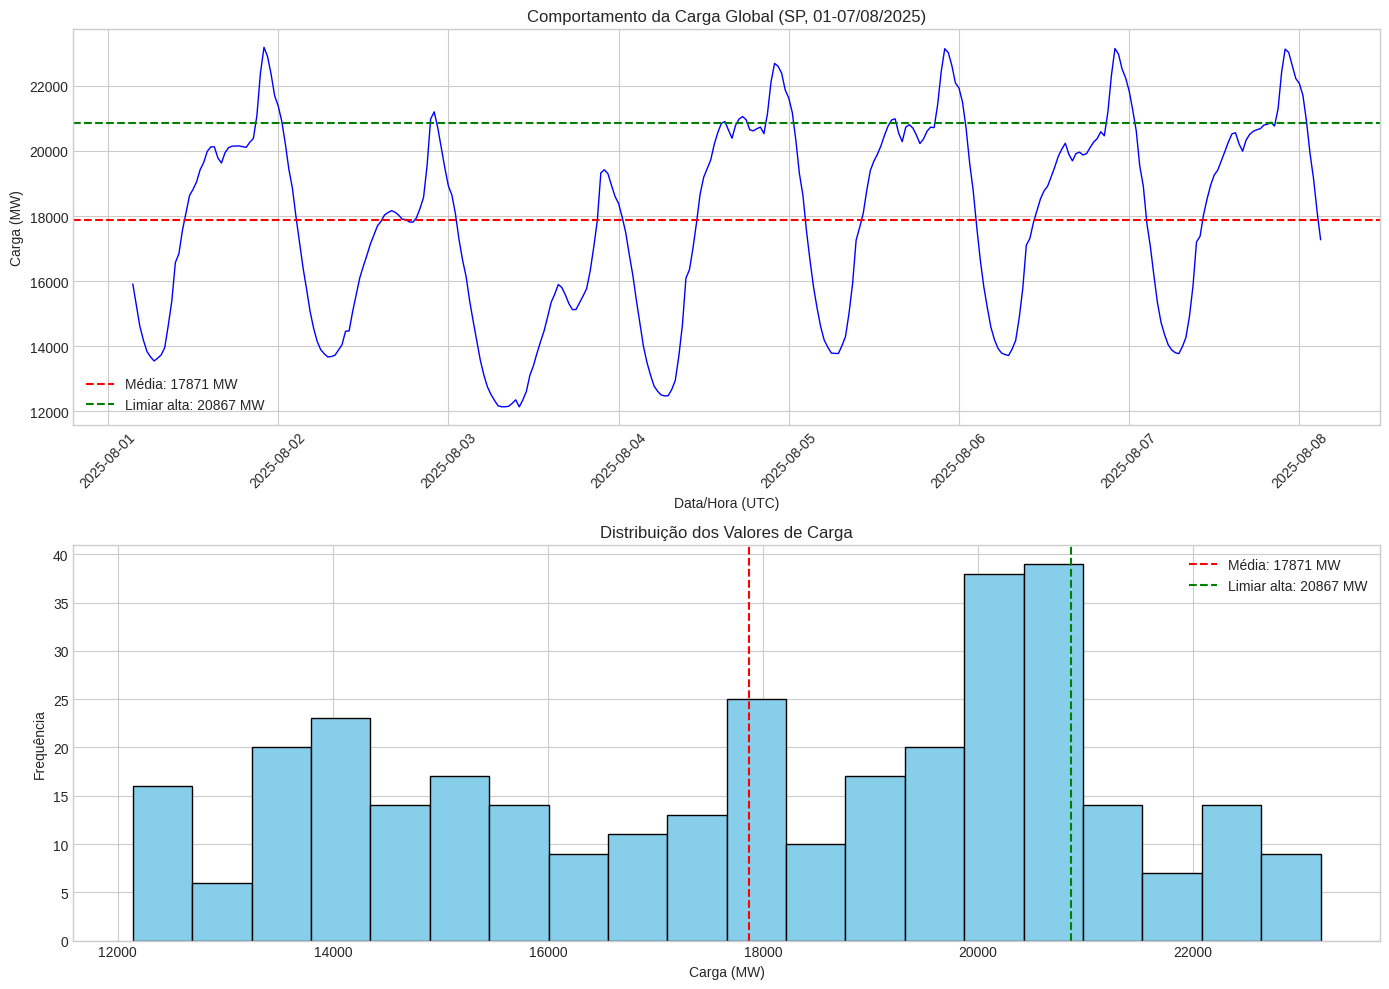

In [12]:
# Desenvolva aqui o DESAFIO 6
print("\n--- DESAFIO 6 ---")

dados_ordenados = dados_filtrados.sort_values('datetime')

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico 1: Série temporal
axes[0].plot(dados_ordenados['datetime'], dados_ordenados['carga_mw'], color='blue', linewidth=1)
axes[0].axhline(y=media, color='red', linestyle='--', label=f'Média: {media:.0f} MW')
axes[0].axhline(y=limiar, color='green', linestyle='--', label=f'Limiar alta: {limiar:.0f} MW')
axes[0].set_title('Comportamento da Carga Global (SP, 01-07/08/2025)')
axes[0].set_xlabel('Data/Hora (UTC)')
axes[0].set_ylabel('Carga (MW)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Histograma
axes[1].hist(dados_filtrados['carga_mw'].dropna(), bins=20, color='skyblue', edgecolor='black')
axes[1].axvline(x=media, color='red', linestyle='--', label=f'Média: {media:.0f} MW')
axes[1].axvline(x=limiar, color='green', linestyle='--', label=f'Limiar alta: {limiar:.0f} MW')
axes[1].set_title('Distribuição dos Valores de Carga')
axes[1].set_xlabel('Carga (MW)')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
print("\n--- VALIDAÇÃO CRÍTICA ---")
# Verificar se a carga está dentro de limites razoáveis (ex: >0)
if (dados_filtrados['carga_mw'] > 0).all():
    print("✅ Todos os valores de carga são positivos.")
else:
    print("⚠️ Existem valores negativos ou zero.")

# Verificar se há datas duplicadas (opcional)
duplicados = dados_filtrados['datetime'].duplicated().sum()
if duplicados == 0:
    print("✅ Não há registros duplicados no tempo.")
else:
    print(f"⚠️ Existem {duplicados} registros duplicados.")

# Verificar consistência dos horários (ex: 24h)
horas_validas = dados_filtrados['hora'].str.match(r'^([0-1]?[0-9]|2[0-3]):[0-5][0-9]:[0-5][0-9]$').all()
if horas_validas:
    print("✅ Todos os horários estão no formato válido HH:MM:SS.")
else:
    print("⚠️ Alguns horários estão fora do formato esperado.")

print("\nValidação concluída.")


--- VALIDAÇÃO CRÍTICA ---
✅ Todos os valores de carga são positivos.
✅ Não há registros duplicados no tempo.
✅ Todos os horários estão no formato válido HH:MM:SS.

Validação concluída.


In [13]:
# Desenvolva aqui o DESAFIO 7
print("\n--- DESAFIO 7 ---")

resumo_resultados = f'''
Região analisada: {dados_filtrados['cod_area'].iloc[0]} (SP)
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: {total_medicoes}
Carga mínima: {min_carga:.2f} MW
Carga máxima: {max_carga:.2f} MW
Carga média: {media_carga:.2f} MW
Mediana: {mediana_carga:.2f} MW
Limiar de alta demanda (90% do máximo): {limiar:.2f} MW
Registros de alta demanda: {qtde_alta} ({perc_alta:.2f}%)
Momento do pico: {pico['data']} às {pico['hora']} (UTC) - carga = {max_carga:.2f} MW
Segundo critério (carga acima da média): {qtde_segundo} registros ({perc_segundo:.2f}%)
'''
print(resumo_resultados)


--- DESAFIO 7 ---

Região analisada: SP (SP)
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: 336
Carga mínima: 12139.25 MW
Carga máxima: 23185.31 MW
Carga média: 17870.83 MW
Mediana: 18199.13 MW
Limiar de alta demanda (90% do máximo): 20866.78 MW
Registros de alta demanda: 50 (14.88%)
Momento do pico: 2025-08-01 às 22:00:00 (UTC) - carga = 23185.31 MW
Segundo critério (carga acima da média): 184 registros (54.76%)

